In [4]:
from ibrl.infrabayesian.world_models import SupraPOMDPWorldModel

num_states  = 1
num_actions = 2
num_obs     = 2  # reward ∈ {0,1}


delta = 0.49

def T_fn(policy):
    # trivial single-state dynamics
    return np.ones((1, num_actions, 1))

def B_fn(policy):
    # policy: shape (num_actions,)
    i = np.argmin(policy)  # adversary targets least likely arm

    B = np.zeros((1, num_obs))  # state x obs
    # we will return different observation models per action via indexing trick below
    # but SupraPOMDP uses B[s, o] only, so we encode per-action via state-action split in R
    # easier: treat obs as reward sampled after action, so we instead encode via R
    raise NotImplementedError

def R_fn(policy):
    i = np.argmin(policy)
    R = np.zeros((1, num_actions, 1))
    R[0, :, 0] = 0.5
    R[0, i, 0] = 0.5 + delta
    return R

num_states = num_actions  # next state = which arm got reward

def T_fn(policy):
    i = np.argmin(policy)
    T = np.zeros((num_states, num_actions, num_states))
    for a in range(num_actions):
        probs = np.full(num_states, 0.5)
        probs[i] = 0.5 + delta
        probs /= probs.sum()
        T[:, a, :] = probs
    return T

def B_fn(policy):
    return np.eye(num_states)  # observe state directly

theta_0 = np.ones(num_states) / num_states
R = np.zeros((num_states, num_actions, num_states))
R[:, :, :] = np.arange(num_states)  # or map states→reward {0,1}

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from ibrl.simulators import simulate
from ibrl.utils import construct_environment,dump_array,sample_action
from ibrl.environments import BernoulliBanditEnvironment
from ibrl.agents import InfraBayesianAgent, DiscreteBayesianAgent, EXP3Agent, ThompsonSamplingBernoulli
from ibrl.infrabayesian import AMeasure,Infradistribution,MultiBernoulliWorldModel

In [5]:
# Possible ranges for reward probabilities for each arm
range1 = (0.5,0.99)
range2 = (0.5,0.99)
range3 = (0.5,0.6)
range3 = (0.5,0.51)

# Convex hull of possible environments
corners = [
    [0.5,0.99],
    [0.5,0.6],
    [0.5,0.51],
    [0.5,0.5],
    [0.99,0.5],
    [0.6,0.5],
    [0.51,0.5],
]

In [6]:
corners

[[0.5, 0.99],
 [0.5, 0.6],
 [0.5, 0.51],
 [0.5, 0.5],
 [0.99, 0.5],
 [0.6, 0.5],
 [0.51, 0.5]]

In [7]:
options = {
    "num_actions": 2,
    "num_steps":   1001,
    "num_runs":    20,
    "seed":        42,
    "verbose":     0,
}
shared = dict(num_actions=2, seed=options["seed"] + 0x01234567, verbose=options["verbose"])

In [8]:
def ClassicalInfraBayesianAgent(num_actions: int, num_hypotheses: int = 5, **kwargs) -> InfraBayesianAgent:
    """Convenience: uniform grid of Bernoulli hypotheses, matching old default behaviour."""
    wm = MultiBernoulliWorldModel(num_arms=num_actions)
    grid = [np.array([1 - p, p]) for p in np.linspace(0.5, 0.99, num_hypotheses)]
    # Each arm gets the same N-point hypothesis grid independently.
    # A single a-measure with N components per arm gives correct independent
    # per-arm Bayesian inference — no joint enumeration needed.
    params = wm.make_params([grid] * num_actions)
    hypotheses = [Infradistribution([AMeasure(params)], world_model=wm)]
    return InfraBayesianAgent(num_actions=num_actions, hypotheses=hypotheses, exploration_prefix=None, **kwargs)

In [10]:
env2 = BernoulliBanditEnvironment(probs=[0.5,0.99], **options)
env3 = BernoulliBanditEnvironment(probs=[0.5,0.6], **options)
env4 = BernoulliBanditEnvironment(probs=[0.5,0.51], **options)
agent3 = ThompsonSamplingBernoulli(**shared)

gamma = np.sqrt(np.log(options["num_actions"])/options["num_actions"]/options["num_steps"])

agent4 = EXP3Agent(**shared, gamma=gamma)
wm = MultiBernoulliWorldModel(num_arms=2)
ib_agent = InfraBayesianAgent(hypotheses=[Infradistribution([
    AMeasure(wm.make_params(np.array([[1-p1,p1],[1-p2,p2]]))) for p1,p2 in corners
], wm)], **shared)
ib_agent2 = InfraBayesianAgent(
    hypotheses=[
        Infradistribution([
            AMeasure(wm.make_params(np.array([[1-p1, p1], [1-p2, p2]])))
        ], wm)
        for p1, p2 in corners
    ],
    **shared
)

wm = SupraPOMDPWorldModel(num_states, num_actions, num_obs)
params = wm.make_params(T_fn, B_fn, theta_0, R)

ib_agent3 = InfraBayesianAgent(
    hypotheses=[Infradistribution([AMeasure(params)], wm)],
    **shared
)

In [12]:
agents = {
    "Infrabayesian": ib_agent,
    "Infrabayesian2": ib_agent2,
    "Infrabayesian3": ib_agent3,
    "Thompson": agent3,
    "Exp3": agent4,
}
envs = {
    "p=[0.5, 0.99]": env2,
    "p=[0.5, 0.6]": env3,
    "p=[0.5, 0.51]": env4,
}

In [13]:
results_bandit = {
    env_name : {
        agent_name : simulate(env,agent,options,0x01234567,0x89abcdef)
        for agent_name,agent in agents.items()
    } for env_name,env in envs.items()
}

TypeError: only length-1 arrays can be converted to Python scalars

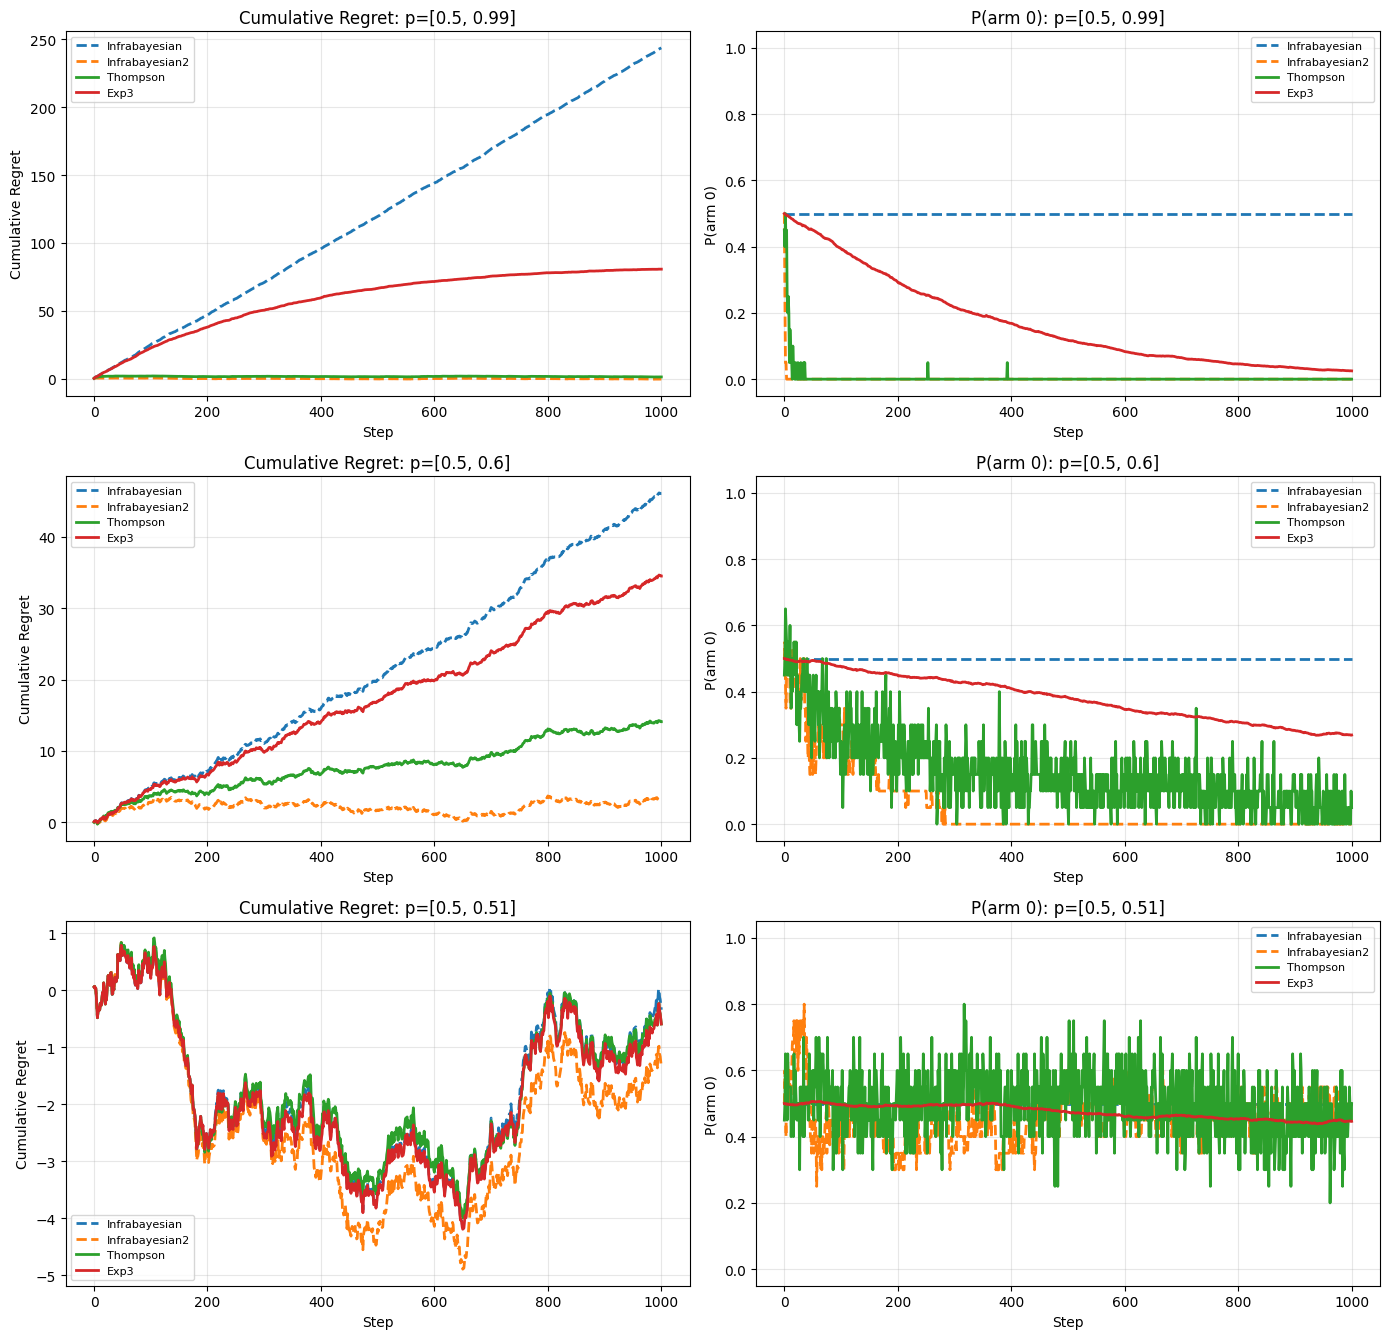

In [67]:
num_envs = len(results_bandit)
fig, axes = plt.subplots(num_envs, 2, figsize=(14, 4.5 * num_envs))

for i, (env_label, agent_results) in enumerate(results_bandit.items()):
    # Cumulative regret
    ax = axes[i, 0]
    for agent_name, res in agent_results.items():
        avg = res["average_reward"][0, :]
        regret = np.cumsum(res["optimal_reward"] - avg)
        ls = "--" if "Infrabayesian" in agent_name else "-"
        ax.plot(regret, label=agent_name, linewidth=2, ls=ls)
    ax.set_title(f"Cumulative Regret: {env_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Regret")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Selection probabilities (arm 0)
    ax = axes[i, 1]
    for agent_name, res in agent_results.items():
        p0 = res["probabilities"][:, :, 0].mean(axis=0)
        ls = "--" if "Infrabayesian" in agent_name else "-"
        ax.plot(p0, label=f"{agent_name}", linewidth=2, ls=ls)
    ax.set_title(f"P(arm 0): {env_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("P(arm 0)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()